In [70]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from matplotlib import cm
import pandas as pd
import japanize_matplotlib

client
right
```
0.6260809,-0.7287946,0.27727395,0.0
0.5277127,0.65780145,0.53741616,0.0
-0.5740574,-0.19014505,0.79643136,0.0
-0.3852316,1.3070072,-0.24187692,0.9999999
```
bothRight
```
0.06430586,-0.6509886,0.7563589,0.0
0.6940623,0.57376546,0.43482298,0.0
-0.71703726,0.49699852,0.48872307,0.0
-0.13179393,1.1662917,-0.42948368,0.9999998
```
bothLeft
```
-0.43660122,0.88827,0.14267299,0.0
-0.6418425,-0.19641805,-0.74125427,0.0
-0.63041043,-0.41520622,0.6558859,0.0
-0.45987153,1.1884942,-0.0532205,0.9999998
```

---

host
right
```
0.092240095,-0.5007555,0.86065996,0.0
0.30278015,0.8375217,0.45484287,0.0
-0.94858617,0.21863598,0.22887182,0.0
-0.091274284,1.3827536,-0.60816413,0.9999996
```
bothRight
```
0.1284489,0.43118837,0.8930717,0.0
0.3820718,0.80950046,-0.4457915,0.0
-0.9151621,0.39847913,-0.060765553,0.0
0.13363218,1.238118,-0.7244158,0.99999964
```
bothLeft
```
-0.5007684,0.116484866,-0.8577073,0.0
0.3800316,-0.8607031,-0.33877146,0.0
-0.7776932,-0.49560198,0.38674507,0.0
-0.45513877,1.1767162,-0.5885545,0.9999995
```

In [71]:
def generateAffineMatrix3DSelfLU(matrix_affineA, matrix_affineAdash):
    """LU分解を用いた最小二乗法でアフィン変換行列を求める"""
    points_A = np.array([mat[:3, 3] for mat in matrix_affineA])
    points_Adash = np.array([mat[:3, 3] for mat in matrix_affineAdash]) 
    
    # 拡張行列を作成
    P = np.hstack((points_A, np.ones((points_A.shape[0], 1))))
    # print(P)
    Q = points_Adash
    # print(Q)

    # 最小二乗法で解を求める
    affine_matrix = leastSquaresMethodLU(P, Q)

    # 4x4のアフィン変換行列を構築
    affine_matrix = np.vstack((affine_matrix.T, np.array([0, 0, 0, 1])))

    return affine_matrix

def LU(A: np.array) -> np.array:
    """LU分解"""
    n = A.shape[0]
    L = np.eye(n)
    U = np.zeros((n, n))
    for i in range(n):
        for j in range(i, n):
            U[i, j] = A[i, j] - np.sum(L[i, :i] * U[:i, j])
        for j in range(i + 1, n):
            L[j, i] = (A[j, i] - np.sum(L[j, :i] * U[:i, i])) / U[i, i]
    return L, U

def eq_solve(P: np.array, Q: np.array) -> np.array:
    # LU分解
    L, U = LU(P)
    n, m = Q.shape  # Q の形状を取得
    y = np.zeros((n, m))  # 前進代入の解ベクトル y を用意

    # 前進代入
    for i in range(n):
        y[i, :] = Q[i, :] - np.dot(L[i, :i], y[:i, :])

    x = np.zeros((n, m))  # 解ベクトル x を用意

    # 後退代入
    for i in range(n - 1, -1, -1):
        if np.abs(U[i, i]) < 1e-8:  # 0除算防止
            print(f"Warning: U[{i}, {i}] is nearly zero. Adding small value.")
            U[i, i] = 1e-8
        x[i, :] = (y[i, :] - np.dot(U[i, i+1:], x[i+1:, :])) / U[i, i]

    return x

def leastSquaresMethodLU(P: np.array, Q: np.array) -> np.array:
    # 最小二乗法で解を求める
    affine_matrix = eq_solve(P.T @ P, P.T) @ Q
    return affine_matrix

In [72]:
client_right = np.array([
    [0.6260809,-0.7287946,0.27727395,0.0],
    [0.5277127,0.65780145,0.53741616,0.0],
    [-0.5740574,-0.19014505,0.79643136,0.0],
    [-0.3852316,1.3070072,-0.24187692,0.9999999]
])

client_both_right = np.array([
    [0.06430586,-0.6509886,0.7563589,0.0],
    [0.6940623,0.57376546,0.43482298,0.0],
    [-0.71703726,0.49699852,0.48872307,0.0],
    [-0.13179393,1.1662917,-0.42948368,0.9999998]
])

client_both_left = np.array([
    [-0.43660122,0.88827,0.14267299,0.0],
    [-0.6418425,-0.19641805,-0.74125427,0.0],
    [-0.63041043,-0.41520622,0.6558859,0.0],
    [-0.45987153,1.1884942,-0.0532205,0.9999998]
])

client_matrix = np.array([
    client_right.T,
    client_both_left.T,
    client_both_right.T,
])

# print("client_matrix")
# print(client_matrix)

host_right = np.array([
    [0.092240095,-0.5007555,0.86065996,0.0],
    [0.30278015,0.8375217,0.45484287,0.0],
    [-0.94858617,0.21863598,0.22887182,0.0],
    [-0.091274284,1.3827536,-0.60816413,0.9999996]
])

host_both_right = np.array([
    [0.1284489,0.43118837,0.8930717,0.0],
    [0.3820718,0.80950046,-0.4457915,0.0],
    [-0.9151621,0.39847913,-0.060765553,0.0],
    [0.13363218,1.238118,-0.7244158,0.99999964]
])

host_both_left = np.array([
    [-0.5007684,0.116484866,-0.8577073,0.0],
    [0.3800316,-0.8607031,-0.33877146,0.0],
    [-0.7776932,-0.49560198,0.38674507,0.0],
    [-0.45513877,1.1767162,-0.5885545,0.9999995]
])

host_matrix = np.array([
    host_right.T,
    host_both_right.T,
    host_both_left.T
])

# print("host_matrix")
# print(host_matrix)

host_to_client_affine_matrix = generateAffineMatrix3DSelfLU(host_matrix, client_matrix)
print("host_to_client_affine_matrix")
print(host_to_client_affine_matrix)
client_to_host_affine_matrix = generateAffineMatrix3DSelfLU(client_matrix, host_matrix)
print("client_to_host_affine_matrix")
print(client_to_host_affine_matrix)

host_to_client_affine_matrix
[[-5.21985838e-01 -3.06889708e-01  1.40137172e-02  5.47509738e-09]
 [-1.01300482e-01  8.40684739e-01 -2.22474867e-01 -1.22141997e-08]
 [ 6.23021862e-01 -2.05158764e-01 -1.62247263e-01  7.86873677e-09]
 [ 0.00000000e+00  0.00000000e+00  0.00000000e+00  1.00000000e+00]]
client_to_host_affine_matrix
[[-1.34293101e+00 -3.88528076e-01  4.16760583e-01  1.41793302e-08]
 [-1.14375729e+00  5.60361063e-01 -8.67161018e-01 -2.93614999e-08]
 [-3.71053146e+00 -2.20049621e+00 -3.46658166e+00  1.91379386e-07]
 [ 0.00000000e+00  0.00000000e+00  0.00000000e+00  1.00000000e+00]]


client_right_cubes
[array([-0.3852316 ,  1.3070072 , -0.24187692]), array([0.6147684 , 2.3070072 , 0.75812308]), array([-1.3852316 ,  2.3070072 ,  0.75812308]), array([-1.3852316 ,  0.3070072 ,  0.75812308]), array([0.6147684 , 0.3070072 , 0.75812308]), array([ 0.6147684 ,  2.3070072 , -1.24187692]), array([-1.3852316 ,  2.3070072 , -1.24187692]), array([-1.3852316 ,  0.3070072 , -1.24187692]), array([ 0.6147684 ,  0.3070072 , -1.24187692])]
client_world_host_hand_cubes
[array([-0.3852316 ,  1.3070072 , -0.24187692,  1.        ]), array([-1.20009343,  1.82391659,  0.01373892,  1.        ]), array([-0.15612175,  2.02651755, -1.23230481,  1.        ]), array([ 0.45765766,  0.34514808, -0.82198728,  1.        ]), array([-0.58631401,  0.14254711,  0.42405644,  1.        ]), array([-1.22812086,  2.26886632,  0.33823344,  1.        ]), array([-0.18414919,  2.47146729, -0.90781028,  1.        ]), array([ 0.42963023,  0.79009781, -0.49749276,  1.        ]), array([-0.61434145,  0.58749685,  0.

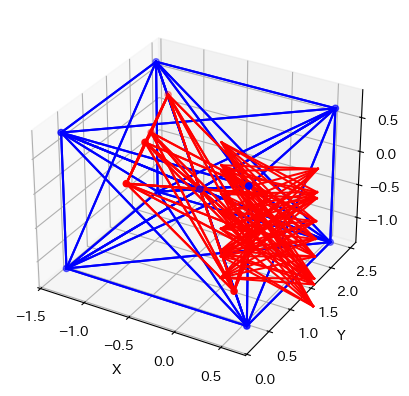

In [73]:
# client側の右手の回転系をhost側から見た時の回転系と比較する
client_right_position = client_right[3, :3]
host_right_position = host_right[3, :3]

baius = 1
# 右手を囲み、回転する直方体の8つの頂点を定義する
client_right_cubes = [
    client_right_position,                                      # 中心
    client_right_position + np.array([baius, baius, baius]),    # 右上前
    client_right_position + np.array([-baius, baius, baius]),   # 左上前
    client_right_position + np.array([-baius, -baius, baius]),  # 左下前
    client_right_position + np.array([baius, -baius, baius]),   # 右下前
    client_right_position + np.array([baius, baius, -baius]),   # 右上後
    client_right_position + np.array([-baius, baius, -baius]),  # 左上後
    client_right_position + np.array([-baius, -baius, -baius]), # 左下後
    client_right_position + np.array([baius, -baius, -baius])   # 右下後
]
host_right_cubes = [
    host_right_position,                                        # 中心
    host_right_position + np.array([baius, baius, baius]),      # 右上前
    host_right_position + np.array([-baius, baius, baius]),     # 左上前
    host_right_position + np.array([-baius, -baius, baius]),    # 左下前
    host_right_position + np.array([baius, -baius, baius]),     # 右下前
    host_right_position + np.array([baius, baius, -baius]),     # 右上後
    host_right_position + np.array([-baius, baius, -baius]),    # 左上後
    host_right_position + np.array([-baius, -baius, -baius]),   # 左下後
    host_right_position + np.array([baius, -baius, -baius])     # 右下後
]

print("client_right_cubes")
print(client_right_cubes)

client_world_host_hand_cubes  = [host_to_client_affine_matrix @ np.array([*cube, 1]) for cube in host_right_cubes]
print("client_world_host_hand_cubes")
print(client_world_host_hand_cubes)

# plot
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
# 3Dグラフの設定
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')

# クライアント側の右手の立方体の描画
ax.scatter(*zip(*client_right_cubes), color='blue', label='Client Right Hand')
# それぞれの頂点を線で結ぶ
for i in range(len(client_right_cubes)):
    for j in range(len(client_right_cubes)):
        if i != j:
            ax.plot(*zip(client_right_cubes[i], client_right_cubes[j]), color='blue')
# ホスト側の右手の立方体の描画
ax.scatter(*zip(*client_world_host_hand_cubes), color='red', label='Host Right Hand')
# 線で結ぶ
for i in range(len(client_world_host_hand_cubes)):
    for j in range(len(client_world_host_hand_cubes)):
        if i != j:
            ax.plot(*zip(client_world_host_hand_cubes[i], client_world_host_hand_cubes[j]), color='red')
plt.show()
